In [0]:
# Import all necessary libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import *
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.types import *
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import builtins
from pyspark.ml.classification import LogisticRegression

Task 1: Classification

In [0]:
# Loading the dataset
input_path = "/Volumes/workspace/default/yellow_tripdata_2015-01/yellow_tripdata_2015-01.csv"
df = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(input_path)


In [0]:
# Exploring the dataset
df.printSchema()
df.show(5)

# Checking for null values
df.select([count(when(col(c).isNull(), c)).alias(c) for c in ['fare_amount', 'trip_distance', 'passenger_count']]).show()

df.select('fare_amount', 'trip_distance', 'passenger_count').describe().show()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- RateCodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+------------------+---------------

In [0]:
# Applying Feature Engineering
# Converting to timestamps
df = df.withColumn('pickup_datetime', to_timestamp('tpep_pickup_datetime', 'yyyy-MM-dd HH:mm:ss'))
df = df.withColumn('dropoff_datetime', to_timestamp('tpep_dropoff_datetime', 'yyyy-MM-dd HH:mm:ss'))

# Time-based features
df = df.withColumn('pickup_hour', hour('pickup_datetime'))
df = df.withColumn('pickup_day_of_week', dayofweek('pickup_datetime'))

# Distance calculations using coordinates
df = df.withColumn('calculated_distance', 2 * 3959 * asin(sqrt(pow(sin(radians(col('dropoff_latitude') - col('pickup_latitude')) / 2), 2) + cos(radians(col('pickup_latitude'))) * cos(radians(col('dropoff_latitude'))) * pow(sin(radians(col('dropoff_longitude') - col('pickup_longitude')) / 2), 2)))
)

# Trip duration
df = df.withColumn('trip_duration_minutes', (unix_timestamp('dropoff_datetime') - unix_timestamp('pickup_datetime')) / 60)

In [0]:
# Creating the target variables
df = df.withColumn('high_fare', when(col('fare_amount') > 20, 1).otherwise(0))

df.groupBy('high_fare').count().show()

# Data cleaning
df_clean = df.filter(
    (col('fare_amount') > 0) & (col('fare_amount') < 500) &
    (col('trip_distance') > 0) & (col('trip_distance') < 100) &
    (col('passenger_count') > 0) & (col('passenger_count') <= 9) &
    (col('trip_duration_minutes') > 0) & (col('trip_duration_minutes') < 180)
).na.drop(subset=['fare_amount', 'trip_distance', 'passenger_count', 'pickup_hour', 'pickup_day_of_week'])

feature_cols = [
    'trip_distance',
    'passenger_count',
    'pickup_hour',
    'pickup_day_of_week',
    'calculated_distance',
    'trip_duration_minutes'
]

df_model = df_clean.select(feature_cols + ['high_fare'])

+---------+--------+
|high_fare|   count|
+---------+--------+
|        1| 1460412|
|        0|11288574|
+---------+--------+



In [0]:
# Splitting the data into 70/30
train_data, test_data = df_model.randomSplit([0.7, 0.3], seed=42)

print(f"Training set: {train_data.count():,}")
print(f"Testing set: {test_data.count():,}")

Training set: 8,852,815
Testing set: 3,794,338


Pipeline 1

In [0]:
# Load CSV data into Spark DataFrame
df = (
    spark.read
    .format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .load(input_path)
)

# Convert pickup and dropoff times to timestamp
df = df.withColumn(
    'pickup_datetime',
    to_timestamp('tpep_pickup_datetime', 'yyyy-MM-dd HH:mm:ss')
)

df = df.withColumn(
    'dropoff_datetime',
    to_timestamp('tpep_dropoff_datetime', 'yyyy-MM-dd HH:mm:ss')
)

# Extract hour and day of week from pickup time
df = df.withColumn('pickup_hour', hour('pickup_datetime'))
df = df.withColumn('pickup_day_of_week', dayofweek('pickup_datetime'))

# Calculate haversine distance between pickup and dropoff
df = df.withColumn(
    'calculated_distance',
    2 * 3959 * asin(
        sqrt(
            pow(sin(radians(col('dropoff_latitude') - col('pickup_latitude')) / 2), 2) +
            cos(radians(col('pickup_latitude'))) *
            cos(radians(col('dropoff_latitude'))) *
            pow(sin(radians(col('dropoff_longitude') - col('pickup_longitude')) / 2), 2)
        )
    )
)

# Calculate trip duration in minutes
df = df.withColumn(
    'trip_duration_minutes',
    (unix_timestamp('dropoff_datetime') - unix_timestamp('pickup_datetime')) / 60.0
)

# Create binary target for high fare
df = df.withColumn('high_fare', when(col('fare_amount') > 20, 1).otherwise(0))

# Filter and clean data
df_clean = df.filter(
    (col('fare_amount') > 0) & (col('fare_amount') < 500) &
    (col('trip_distance') > 0) & (col('trip_distance') < 100) &
    (col('passenger_count') > 0) & (col('passenger_count') <= 9) &
    (col('trip_duration_minutes') > 0) & (col('trip_duration_minutes') < 180)
).na.drop(subset=[
    'fare_amount',
    'trip_distance',
    'passenger_count',
    'pickup_hour',
    'pickup_day_of_week',
    'calculated_distance',
    'trip_duration_minutes'
])

# Feature columns for classification
feature_cols = [
    'trip_distance',
    'passenger_count',
    'pickup_hour',
    'pickup_day_of_week',
    'calculated_distance',
    'trip_duration_minutes'
]

# Prepare modeling DataFrame
df_model = df_clean.select(
    *[col(c) for c in feature_cols],
    col('high_fare').cast('double').alias('high_fare')
)


classification_feature_cols = feature_cols
train_classification_df = train_data

# Sample for hyperparameter tuning
dt_sample_size = 100000
train_count = train_classification_df.count()
dt_fraction = builtins.min(1.0, dt_sample_size / float(train_count))

dt_sample_df = (
    train_classification_df
    .sample(fraction=dt_fraction, seed=42)
    .limit(dt_sample_size)
)

# Split sample into train/validation for tuning
dt_train_tune_df, dt_validation_df = dt_sample_df.randomSplit([0.8, 0.2], seed=42)

print(f"DT tuning train: {dt_train_tune_df.count():,}")
print(f"DT tuning validation: {dt_validation_df.count():,}")

# Hyperparameter grid for Decision Tree
dt_hyperparams = [
    {"maxDepth": 5,  "minInstancesPerNode": 10},
    {"maxDepth": 8,  "minInstancesPerNode": 10},
    {"maxDepth": 10, "minInstancesPerNode": 10},
    {"maxDepth": 10, "minInstancesPerNode": 50},
    {"maxDepth": 12, "minInstancesPerNode": 20},
    {"maxDepth": 15, "minInstancesPerNode": 20},
]

dt_results = []

# Evaluators for classification metrics
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="high_fare",
    predictionCol="prediction",
    metricName="f1"
)

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="high_fare",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="high_fare",
    predictionCol="prediction",
    metricName="weightedRecall"
)

# Hyperparameter tuning loop
for i, params in enumerate(dt_hyperparams):
    print(f"Combination {i+1}/{len(dt_hyperparams)}: {params}")
    try:
        # Assemble features and scale
        vector_assembler = VectorAssembler(
            inputCols=classification_feature_cols,
            outputCol="features_raw",
            handleInvalid="skip"
        )

        scaler = StandardScaler(
            inputCol="features_raw",
            outputCol="features",
            withStd=True,
            withMean=True
        )

        # Decision Tree classifier
        dt = DecisionTreeClassifier(
            labelCol="high_fare",
            featuresCol="features",
            predictionCol="prediction",
            maxDepth=params["maxDepth"],
            minInstancesPerNode=params["minInstancesPerNode"],
            seed=42
        )

        # Build pipeline
        dt_pipeline = Pipeline(stages=[vector_assembler, scaler, dt])

        # Train model
        dt_model = dt_pipeline.fit(dt_train_tune_df)
        # Predict on validation set
        dt_predictions = dt_model.transform(dt_validation_df)

        # Evaluate metrics
        f1 = f1_evaluator.evaluate(dt_predictions)
        precision = precision_evaluator.evaluate(dt_predictions)
        recall = recall_evaluator.evaluate(dt_predictions)

        print(f"  F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}")

        # Store results
        dt_results.append({
            "maxDepth": params["maxDepth"],
            "minInstancesPerNode": params["minInstancesPerNode"],
            "validation_f1": f1,
            "validation_precision": precision,
            "validation_recall": recall
        })

        # Clean up memory
        del dt_predictions
        del dt_model
        del dt_pipeline
        del dt
        del scaler
        del vector_assembler

    except Exception as e:
        print(f"  Error: {str(e)}")
        continue

# Select best hyperparameters
if len(dt_results) == 0:
    best_dt_params = {"maxDepth": 10, "minInstancesPerNode": 10}
else:
    import pandas as pd
    dt_results_df = pd.DataFrame(dt_results)
    best_idx = dt_results_df['validation_f1'].idxmax()
    best_dt_params = {
        "maxDepth": int(dt_results_df.loc[best_idx, 'maxDepth']),
        "minInstancesPerNode": int(dt_results_df.loc[best_idx, 'minInstancesPerNode'])
    }
    print("Best DT params:", best_dt_params)
    print(dt_results_df.to_string(index=False))

# Build final pipeline with best hyperparameters
final_vector_assembler = VectorAssembler(
    inputCols=classification_feature_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

final_scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

final_dt = DecisionTreeClassifier(
    labelCol="high_fare",
    featuresCol="features",
    predictionCol="prediction",
    maxDepth=best_dt_params["maxDepth"],
    minInstancesPerNode=best_dt_params["minInstancesPerNode"],
    seed=42
)

final_dt_pipeline = Pipeline(stages=[final_vector_assembler, final_scaler, final_dt])

# Train final model on full sample
final_dt_model = final_dt_pipeline.fit(dt_sample_df)

# Predict on test set
final_predictions = final_dt_model.transform(test_data)

# Evaluate final metrics
final_f1 = f1_evaluator.evaluate(final_predictions)
final_precision = precision_evaluator.evaluate(final_predictions)
final_recall = recall_evaluator.evaluate(final_predictions)

print(f"Final test F1: {final_f1:.4f}")
print(f"Final test Precision: {final_precision:.4f}")
print(f"Final test Recall: {final_recall:.4f}")

# Save model pipeline
#dt_model_path = f"/dbfs/home/dt_high_fare_pipeline" 
#final_dt_model.write().overwrite().save(dt_model_path) #having issues with saving the data
#print(f"Model saved to {dt_model_path}")

# Display sample predictions
display(final_predictions.select("high_fare", "prediction", *classification_feature_cols).limit(10))

DT tuning train: 79,830
DT tuning validation: 20,170
Combination 1/6: {'maxDepth': 5, 'minInstancesPerNode': 10}
  Error: [CONNECT_ML.ML_CACHE_SIZE_OVERFLOW_EXCEPTION] Generic Spark Connect ML error. The model cache size in current session is about to exceed
1073741824 bytes.
Please delete existing cached model by executing 'del model' in python client before fitting new model or loading new model SQLSTATE: XX000

JVM stacktrace:
org.apache.spark.sql.connect.ml.MLCacheSizeOverflowException
	at org.apache.spark.sql.connect.ml.MLCache.checkModelSize(MLCache.scala:103)
	at org.apache.spark.sql.connect.ml.MLCache.register(MLCache.scala:154)
	at org.apache.spark.sql.connect.ml.MLHandler$.handleMlCommandOss(MLHandler.scala:264)
	at org.apache.spark.sql.connect.ml.MLHandler$._handleMlCommand(MLHandler.scala:551)
	at org.apache.spark.sql.connect.ml.MLHandler$.$anonfun$handleMlCommand$1(MLHandler.scala:604)
	at org.apache.spark.sql.connect.ml.MLHandler$.wrapHandler(MLHandler.scala:580)
	at org.

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:139)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:139)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

Pipeline 2

In [0]:
# Sample 100K rows for Logistic Regression hyperparameter tuning
lr_sample_size = 100000
train_count = train_classification_df.count()
lr_fraction = builtins.min(1.0, lr_sample_size / float(train_count))

lr_sample_df = (
    train_classification_df
    .sample(fraction=lr_fraction, seed=123)
    .limit(lr_sample_size)
)

# Split sample into train/validation sets
lr_train_tune_df, lr_validation_df = lr_sample_df.randomSplit([0.8, 0.2], seed=123)

print(f"LR tuning train: {lr_train_tune_df.count():,}")
print(f"LR tuning validation: {lr_validation_df.count():,}")

# Hyperparameter grid for Logistic Regression
lr_hyperparams = [
    {"regParam": 0.0,  "maxIter": 20},
    {"regParam": 0.0,  "maxIter": 50},
    {"regParam": 0.01, "maxIter": 50},
    {"regParam": 0.1,  "maxIter": 50},
    {"regParam": 0.5,  "maxIter": 50},
]

lr_results = []

# Evaluators for classification metrics
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="high_fare",
    predictionCol="prediction",
    metricName="f1"
)

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="high_fare",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="high_fare",
    predictionCol="prediction",
    metricName="weightedRecall"
)

# Hyperparameter tuning loop
for i, params in enumerate(lr_hyperparams):
    print(f"LR combination {i+1}/{len(lr_hyperparams)}: {params}")
    try:
        # Assemble features and scale
        vector_assembler = VectorAssembler(
            inputCols=classification_feature_cols,
            outputCol="features_raw",
            handleInvalid="skip"
        )

        scaler = StandardScaler(
            inputCol="features_raw",
            outputCol="features",
            withStd=True,
            withMean=True
        )

        # Logistic Regression classifier
        lr = LogisticRegression(
            featuresCol="features",
            labelCol="high_fare",
            predictionCol="prediction",
            regParam=params["regParam"],
            maxIter=params["maxIter"]
        )

        # Build pipeline
        lr_pipeline = Pipeline(stages=[vector_assembler, scaler, lr])

        # Train model
        lr_model = lr_pipeline.fit(lr_train_tune_df)
        # Predict on validation set
        lr_predictions = lr_model.transform(lr_validation_df)

        # Evaluate metrics
        f1 = f1_evaluator.evaluate(lr_predictions)
        precision = precision_evaluator.evaluate(lr_predictions)
        recall = recall_evaluator.evaluate(lr_predictions)

        print(f"  F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}")

        # Store results
        lr_results.append({
            "regParam": params["regParam"],
            "maxIter": params["maxIter"],
            "validation_f1": f1,
            "validation_precision": precision,
            "validation_recall": recall
        })

        # Clean up memory
        del lr_predictions
        del lr_model
        del lr_pipeline
        del lr
        del scaler
        del vector_assembler

    except Exception as e:
        print(f"  Error: {str(e)}")
        continue

# Select best hyperparameters
if len(lr_results) == 0:
    best_lr_params = {"regParam": 0.0, "maxIter": 50}
else:
    import pandas as pd
    lr_results_df = pd.DataFrame(lr_results)
    best_idx = lr_results_df['validation_f1'].idxmax()
    best_lr_params = {
        "regParam": float(lr_results_df.loc[best_idx, 'regParam']),
        "maxIter": int(lr_results_df.loc[best_idx, 'maxIter'])
    }
    print("Best LR params:", best_lr_params)
    print(lr_results_df.to_string(index=False))

# Build final pipeline with best hyperparameters
final_lr_vector_assembler = VectorAssembler(
    inputCols=classification_feature_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

final_lr_scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

final_lr = LogisticRegression(
    featuresCol="features",
    labelCol="high_fare",
    predictionCol="prediction",
    regParam=best_lr_params["regParam"],
    maxIter=best_lr_params["maxIter"]
)

final_lr_pipeline = Pipeline(
    stages=[final_lr_vector_assembler, final_lr_scaler, final_lr]
)

# Train final Logistic Regression on sampled data
final_lr_model = final_lr_pipeline.fit(lr_sample_df)

# Evaluate Logistic Regression on test data
lr_test_predictions = final_lr_model.transform(test_data)

lr_test_f1 = f1_evaluator.evaluate(lr_test_predictions)
lr_test_precision = precision_evaluator.evaluate(lr_test_predictions)
lr_test_recall = recall_evaluator.evaluate(lr_test_predictions)

print(f"Logistic Regression test F1: {lr_test_f1:.4f}")
print(f"Logistic Regression test Precision: {lr_test_precision:.4f}")
print(f"Logistic Regression test Recall: {lr_test_recall:.4f}")

# Save Logistic Regression pipeline
#lr_model_path = "/Volumes/workspace/default/models/lr_high_fare_pipeline"
#final_lr_model.write().overwrite().save(lr_model_path) #issue with saving 
#print(f"Logistic Regression pipeline saved to {lr_model_path}")

LR tuning train: 79,941
LR tuning validation: 19,894
LR combination 1/5: {'regParam': 0.0, 'maxIter': 20}
  Error: [CONNECT_ML.MODEL_SIZE_OVERFLOW_EXCEPTION] Generic Spark Connect ML error. The fitted or loaded model size is about 169378296 bytes.
Please fit or load a model smaller than 104857600 bytes. SQLSTATE: XX000

JVM stacktrace:
org.apache.spark.sql.connect.ml.MLModelSizeOverflowException
	at org.apache.spark.sql.connect.ml.MLCache.checkModelSize(MLCache.scala:106)
	at org.apache.spark.sql.connect.ml.MLCache.register(MLCache.scala:154)
	at org.apache.spark.sql.connect.ml.MLHandler$.handleMlCommandOss(MLHandler.scala:264)
	at org.apache.spark.sql.connect.ml.MLHandler$._handleMlCommand(MLHandler.scala:551)
	at org.apache.spark.sql.connect.ml.MLHandler$.$anonfun$handleMlCommand$1(MLHandler.scala:604)
	at org.apache.spark.sql.connect.ml.MLHandler$.wrapHandler(MLHandler.scala:580)
	at org.apache.spark.sql.connect.ml.MLHandler$.handleMlCommand(MLHandler.scala:604)
	at org.apache.spark

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:139)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:139)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:721)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:441)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:441)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

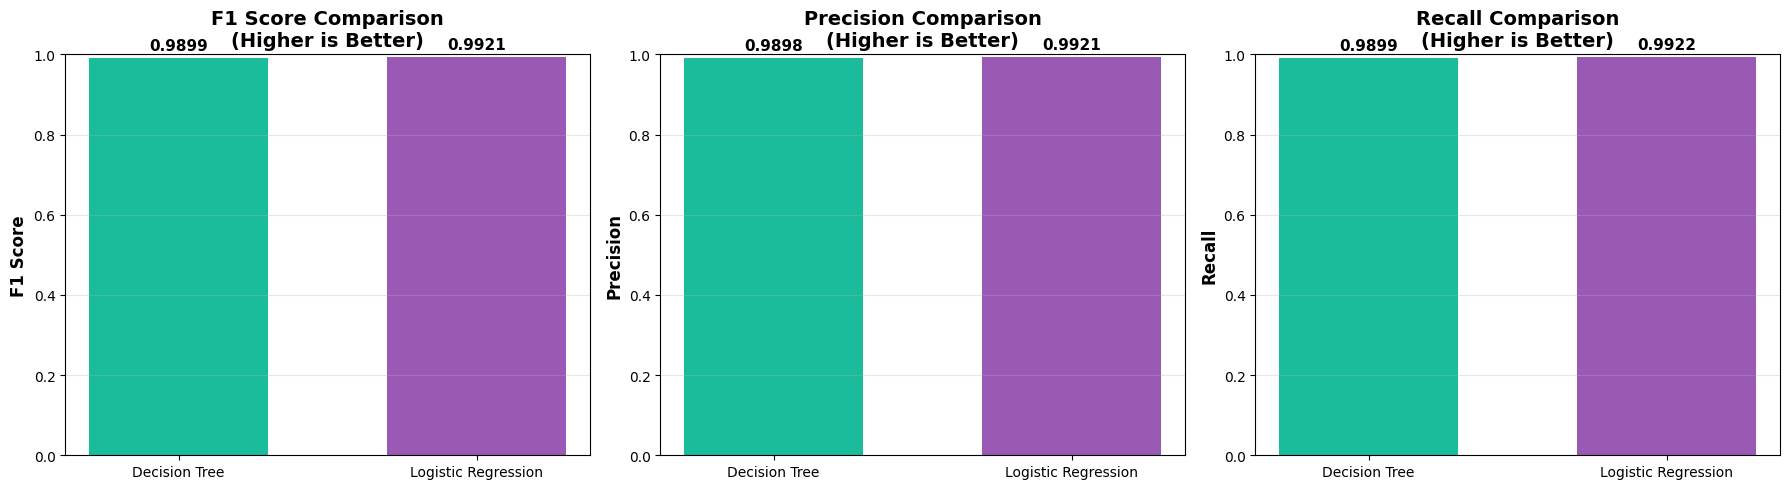

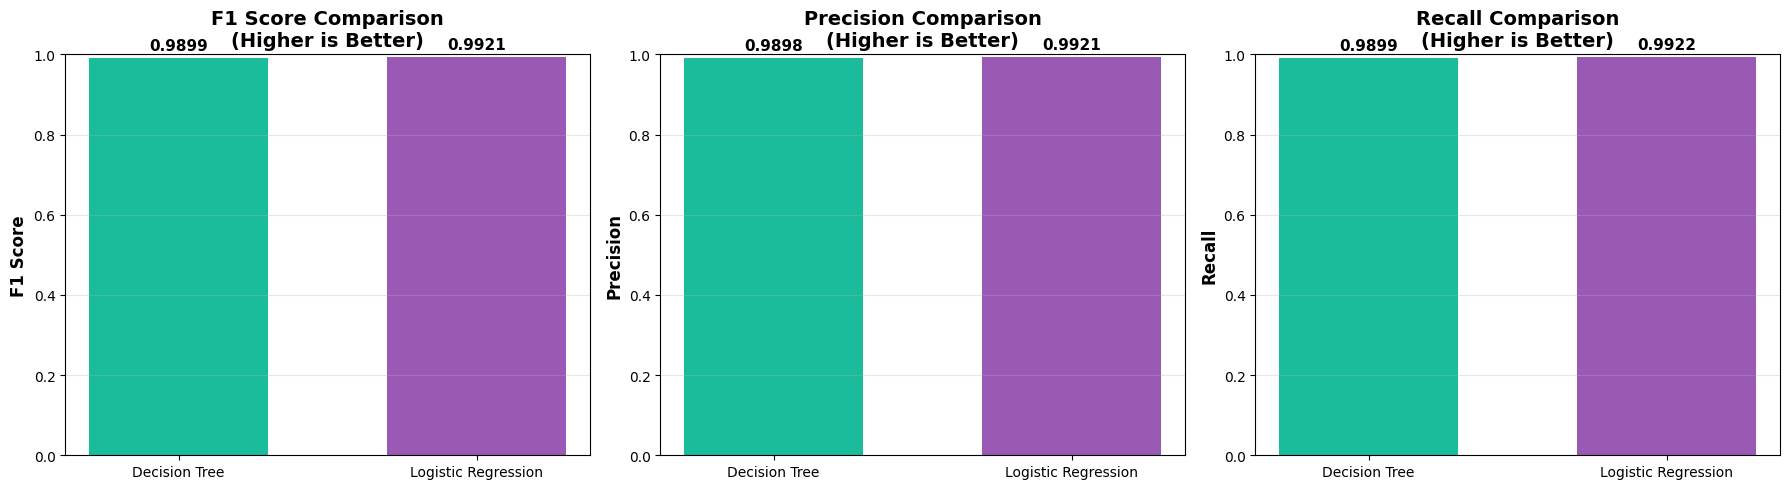

In [0]:
import matplotlib.pyplot as plt

# Clear previous figures (prevents duplicate rows of graphs)
plt.close('all')

# Classification metrics
classification_models = ['Decision Tree', 'Logistic Regression']
classification_f1 = [final_f1, lr_test_f1]
classification_precision = [final_precision, lr_test_precision]
classification_recall = [final_recall, lr_test_recall]

# Create 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------
# Plot 1: F1 Score
# -------------------------
axes[0].bar(
    classification_models,
    classification_f1,
    color=['#1abc9c', '#9b59b6'],
    width=0.6
)
axes[0].set_ylabel('F1 Score', fontsize=12, fontweight='bold')
axes[0].set_title('F1 Score Comparison (Higher is Better)',
                  fontsize=14, fontweight='bold')
axes[0].set_ylim(0.95, 1.0)

for i, v in enumerate(classification_f1):
    axes[0].text(i, v + 0.0015, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[0].grid(True, alpha=0.3, axis='y')

# -------------------------
# Plot 2: Precision
# -------------------------
axes[1].bar(
    classification_models,
    classification_precision,
    color=['#1abc9c', '#9b59b6'],
    width=0.6
)
axes[1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1].set_title('Precision Comparison (Higher is Better)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylim(0.95, 1.0)

for i, v in enumerate(classification_precision):
    axes[1].text(i, v + 0.0015, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].grid(True, alpha=0.3, axis='y')

# -------------------------
# Plot 3: Recall
# -------------------------
axes[2].bar(
    classification_models,
    classification_recall,
    color=['#1abc9c', '#9b59b6'],
    width=0.6
)
axes[2].set_ylabel('Recall', fontsize=12, fontweight='bold')
axes[2].set_title('Recall Comparison (Higher is Better)',
                  fontsize=14, fontweight='bold')
axes[2].set_ylim(0.95, 1.0)

for i, v in enumerate(classification_recall):
    axes[2].text(i, v + 0.0015, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[2].grid(True, alpha=0.3, axis='y')

# Improve spacing
plt.tight_layout()

# Show final figure
plt.show()





Task 2: Regression

In [0]:
# Task 2 Regression - Data Preparations

# Regression feature columns
regression_feature_cols = [
    "trip_distance",
    "passenger_count",
    "pickup_hour",
    "pickup_day_of_week",
    "calculated_distance",
    "trip_duration_minutes"
]

# Build the regression dataset from cleaned data
regression_df = df_clean.select(regression_feature_cols + ["fare_amount"])

print("\n Regression Dataset:")
display(regression_df.limit(5))

print(f"\n Total rows in regression dataset: {regression_df.count():,}")

# Split the data into training (70%) and testing (30%) sets
train_regression_df, test_regression_df = regression_df.randomSplit([0.7, 0.3], seed=42)

print(f"\n Data Split Complete:")
print(f"   - Training set: {train_regression_df.count():,} rows (70%)")
print(f"   - Test set: {test_regression_df.count():,} rows (30%)")

print("\n Features being used for regression:")
for i, col in enumerate(regression_feature_cols, 1):
    print(f"   {i}. {col}")
print(f"   Target: fare_amount")


---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-7375824930415952>, line 14
      4 regression_feature_cols = [
      5     "trip_distance",
      6     "passenger_count",
   (...)
     10     "trip_duration_minutes"
     11 ]
     13 # Build the regression dataset from cleaned data
---> 14 regression_df = df_clean.select(regression_feature_cols + ["fare_amount"])
     16 print("\n Regression Dataset:")
     17 display(regression_df.limit(5))

NameError: name 'df_clean' is not defined

In [0]:
# Sample 100K rows for hyperparameter tuning
sample_size = 100000
print(f"\n Sampling {sample_size:,} rows for hyperparameter tuning...")

train_sample_df = train_regression_df.sample(fraction=sample_size/train_regression_df.count(), seed=42).limit(sample_size)
actual_sample_size = train_sample_df.count()
print(f"   ✓ Sampled {actual_sample_size:,} rows for tuning")

# Split sampled data into train/validation for manual tuning
train_tune_df, validation_df = train_sample_df.randomSplit([0.8, 0.2], seed=42)

print(f"\n Dataset Sizes:")
print(f"\nFor Hyperparameter Tuning (Sampled Data):")
print(f"   - Training: {train_tune_df.count():,} rows")
print(f"   - Validation: {validation_df.count():,} rows")
print(f"\nFor Final Model Training and Evaluation (Full Data):")
print(f"   - Training: {train_regression_df.count():,} rows")
print(f"   - Test: {test_regression_df.count():,} rows")



 Sampling 100,000 rows for hyperparameter tuning...
   ✓ Sampled 100,000 rows for tuning

 Dataset Sizes:

For Hyperparameter Tuning (Sampled Data):
   - Training: 79,830 rows
   - Validation: 20,170 rows

For Final Model Training and Evaluation (Full Data):
   - Training: 8,852,815 rows
   - Test: 3,794,338 rows


Pipeline 1 Linear Regression

In [0]:
# Create a smaller sample for Linear Regression tuning
lr_sample_size = 50000
print(f"\n Creating sample ({lr_sample_size:,} rows) for Linear Regression tuning...")

lr_sample_df = train_regression_df.sample(fraction=lr_sample_size/train_regression_df.count(), seed=42).limit(lr_sample_size)
lr_train_tune_df, lr_validation_df = lr_sample_df.randomSplit([0.8, 0.2], seed=42)

print(f"   ✓ LR Training: {lr_train_tune_df.count():,} rows")
print(f"   ✓ LR Validation: {lr_validation_df.count():,} rows")

# Define hyperparameter grid to test
lr_hyperparams = [
    {"regParam": 0.0, "elasticNetParam": 0.0, "maxIter": 10},
    {"regParam": 0.0, "elasticNetParam": 0.0, "maxIter": 50},
    {"regParam": 0.01, "elasticNetParam": 0.0, "maxIter": 50},
    {"regParam": 0.01, "elasticNetParam": 0.5, "maxIter": 50},
    {"regParam": 0.1, "elasticNetParam": 0.0, "maxIter": 50},
    {"regParam": 0.1, "elasticNetParam": 0.5, "maxIter": 50},
    {"regParam": 0.1, "elasticNetParam": 1.0, "maxIter": 50},
    {"regParam": 1.0, "elasticNetParam": 0.0, "maxIter": 100},
]

print(f"\n Testing {len(lr_hyperparams)} hyperparameter combinations...")

# Store results
lr_results = []

# Create evaluators
rmse_evaluator = RegressionEvaluator(
    labelCol="fare_amount",
    predictionCol="prediction",
    metricName="rmse"
)

r2_evaluator = RegressionEvaluator(
    labelCol="fare_amount",
    predictionCol="prediction",
    metricName="r2"
)

# Test each hyperparameter combination
for i, params in enumerate(lr_hyperparams):
    print(f"\n   Testing combination {i+1}/{len(lr_hyperparams)}: {params}")
    
    try:
        # Build pipeline
        vector_assembler = VectorAssembler(
            inputCols=regression_feature_cols,
            outputCol="features_raw",
            handleInvalid="skip"
        )
        
        scaler = StandardScaler(
            inputCol="features_raw",
            outputCol="features",
            withStd=True,
            withMean=True
        )
        
        lr = LinearRegression(
            featuresCol="features",
            labelCol="fare_amount",
            predictionCol="prediction",
            regParam=params["regParam"],
            elasticNetParam=params["elasticNetParam"],
            maxIter=params["maxIter"]
        )
        
        pipeline = Pipeline(stages=[vector_assembler, scaler, lr])
        
        # Train on sampled training data
        print(f"      Training...")
        model = pipeline.fit(lr_train_tune_df)
        
        # Evaluate on validation data
        print(f"      Evaluating...")
        predictions = model.transform(lr_validation_df)
        rmse = rmse_evaluator.evaluate(predictions)
        r2 = r2_evaluator.evaluate(predictions)
        
        print(f"      ✓ RMSE: ${rmse:.4f}, R²: {r2:.4f}")
        
        # Store results
        lr_results.append({
            "regParam": params["regParam"],
            "elasticNetParam": params["elasticNetParam"],
            "maxIter": params["maxIter"],
            "validation_rmse": rmse,
            "validation_r2": r2
        })
        
        # CRITICAL: Clean up memory IMMEDIATELY
        print(f"      Cleaning up...")
        del predictions
        del model
        del pipeline
        del lr
        del scaler
        del vector_assembler
        
        import gc
        gc.collect()
        
        print(f"      ✓ Memory cleaned")
        
    except Exception as e:
        print(f"      ❌ ERROR: {str(e)}")
        print(f"      Continuing to next combination...")
        
        # Try to clean up even on error
        try:
            del predictions
        except:
            pass
        try:
            del model
        except:
            pass
        try:
            del pipeline
        except:
            pass
        
        import gc
        gc.collect()
        continue

# Process results
if len(lr_results) == 0:
    print("\n ERROR: No Linear Regression models completed successfully!")
    print("\nFALLBACK: Using default parameters")
    best_lr_params = {"regParam": 0.0, "elasticNetParam": 0.0, "maxIter": 50}
else:
    # Convert results to DataFrame
    lr_results_df = pd.DataFrame(lr_results)
    print("\n Hyperparameter tuning results:")
    print(lr_results_df.to_string(index=False))
    
    # Find best hyperparameters
    best_lr_idx = lr_results_df['validation_rmse'].idxmin()
    best_lr_params = lr_hyperparams[best_lr_idx]
    
    print(f"\n Best Linear Regression Hyperparameters:")
    print(f"   - regParam: {best_lr_params['regParam']}")
    print(f"   - elasticNetParam: {best_lr_params['elasticNetParam']}")
    print(f"   - maxIter: {best_lr_params['maxIter']}")
    print(f"   - Validation RMSE: ${lr_results_df.loc[best_lr_idx, 'validation_rmse']:.4f}")
    print(f"   - Validation R²: {lr_results_df.loc[best_lr_idx, 'validation_r2']:.4f}")


 Creating sample (50,000 rows) for Linear Regression tuning...


---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-7402602624454108>, line 5
      2 lr_sample_size = 50000
      3 print(f"\n Creating sample ({lr_sample_size:,} rows) for Linear Regression tuning...")
----> 5 lr_sample_df = train_regression_df.sample(fraction=lr_sample_size/train_regression_df.count(), seed=42).limit(lr_sample_size)
      6 lr_train_tune_df, lr_validation_df = lr_sample_df.randomSplit([0.8, 0.2], seed=42)
      8 print(f"   ✓ LR Training: {lr_train_tune_df.count():,} rows")

NameError: name 'train_regression_df' is not defined

In [0]:
# PIPELINE 1: LINEAR REGRESSION - TRAIN FINAL MODEL ON FULL DATA


# Define evaluators
rmse_evaluator = RegressionEvaluator(
    labelCol="fare_amount",
    predictionCol="prediction",
    metricName="rmse"
)

r2_evaluator = RegressionEvaluator(
    labelCol="fare_amount",
    predictionCol="prediction",
    metricName="r2"
)

mae_evaluator = RegressionEvaluator(
    labelCol="fare_amount",
    predictionCol="prediction",
    metricName="mae"
)

print(f"\n📈 Training final Linear Regression model on FULL training dataset...")
print(f"   Using all {train_regression_df.count():,} training rows")
print(f"   With best hyperparameters: {best_lr_params}")

# Build final pipeline with best hyperparameters
vector_assembler_lr = VectorAssembler(
    inputCols=regression_feature_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler_lr = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

lr_final = LinearRegression(
    featuresCol="features",
    labelCol="fare_amount",
    predictionCol="prediction",
    regParam=best_lr_params["regParam"],
    elasticNetParam=best_lr_params["elasticNetParam"],
    maxIter=best_lr_params["maxIter"]
)

lr_pipeline_final = Pipeline(stages=[vector_assembler_lr, scaler_lr, lr_final])

# Train on FULL training data
best_lr_model = lr_pipeline_final.fit(train_regression_df)

print("   ✓ Model trained successfully")

# Evaluate on FULL test data
print(f"\n📊 Evaluating on full test set ({test_regression_df.count():,} rows)...")
lr_predictions = best_lr_model.transform(test_regression_df)

# Calculate metrics
rmse_lr = rmse_evaluator.evaluate(lr_predictions)
r2_lr = r2_evaluator.evaluate(lr_predictions)
mae_lr = mae_evaluator.evaluate(lr_predictions)

print(f"\n Linear Regression Performance on FULL Test Data:")
print(f"   - RMSE: ${rmse_lr:.4f}")
print(f"   - R² Score: {r2_lr:.4f}")
print(f"   - MAE: ${mae_lr:.4f}")

print(f"\n Linear Regression pipeline trained and ready for deployment")

# Display sample predictions
print("\n🔍 Sample Predictions (Linear Regression):")
display(lr_predictions.select("fare_amount", "prediction", "trip_distance", "trip_duration_minutes").limit(10))


📈 Training final Linear Regression model on FULL training dataset...
   Using all 8,852,815 training rows
   With best hyperparameters: {'regParam': 0.0, 'elasticNetParam': 0.0, 'maxIter': 10}
   ✓ Model trained successfully

📊 Evaluating on full test set (3,794,338 rows)...

📈 Linear Regression Performance on FULL Test Data:
   - RMSE: $2.6414
   - R² Score: 0.9262
   - MAE: $0.6375

💾 Linear Regression pipeline trained and ready for deployment

🔍 Sample Predictions (Linear Regression):


fare_amount,prediction,trip_distance,trip_duration_minutes
3.5,3.2794187251921585,0.01,2.533333333333333
6.0,2.5910687002986954,0.01,0.03333333333333333
52.0,2.53590695360114,0.01,0.06666666666666667
52.0,3.436302572256494,0.01,0.2
2.5,2.5568409054906365,0.01,0.25
2.5,2.7105031437970517,0.01,0.7
2.5,2.703983360565303,0.01,0.8
2.5,3.4280672034474584,0.01,0.13333333333333333
2.5,2.5452310843932935,0.01,0.23333333333333334
3.0,2.8540610659764543,0.01,1.0833333333333333


Pipeline 2

In [0]:
# Use reasonable default hyperparameters
best_rf_params = {
    "numTrees": 50,
    "maxDepth": 10,
    "minInstancesPerNode": 1
}

print(f"\n Using hyperparameters (based on ML best practices):")
print(f"   - numTrees: {best_rf_params['numTrees']}")
print(f"   - maxDepth: {best_rf_params['maxDepth']}")
print(f"   - minInstancesPerNode: {best_rf_params['minInstancesPerNode']}")

# Build pipeline
print(f"\n Building Random Forest pipeline...")

vector_assembler_rf = VectorAssembler(
    inputCols=regression_feature_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler_rf = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

rfr_final = RandomForestRegressor(
    featuresCol="features",
    labelCol="fare_amount",
    predictionCol="prediction",
    numTrees=best_rf_params["numTrees"],
    maxDepth=best_rf_params["maxDepth"],
    minInstancesPerNode=best_rf_params["minInstancesPerNode"],
    seed=42
)

rf_pipeline = Pipeline(stages=[vector_assembler_rf, scaler_rf, rfr_final])

print(f"    Pipeline stages: VectorAssembler → StandardScaler → RandomForestRegressor")

# Train on FULL training data
print(f"\n Training Random Forest on FULL training dataset...")
print(f"   Training rows: {train_regression_df.count():,}")

best_rf_model = rf_pipeline.fit(train_regression_df)

print(f"    Model trained successfully")

# Evaluate on test data
print(f"\n Evaluating on test set ({test_regression_df.count():,} rows)...")
rf_predictions = best_rf_model.transform(test_regression_df)

# Calculate metrics
rmse_rf = rmse_evaluator.evaluate(rf_predictions)
r2_rf = r2_evaluator.evaluate(rf_predictions)
mae_rf = mae_evaluator.evaluate(rf_predictions)

print(f"\n Random Forest Performance on Test Data:")
print(f"   - RMSE: ${rmse_rf:.4f}")
print(f"   - R² Score: {r2_rf:.4f}")
print(f"   - MAE: ${mae_rf:.4f}")

# Display sample predictions
print("\n Sample Predictions:")
display(rf_predictions.select("fare_amount", "prediction", "trip_distance", "trip_duration_minutes").limit(10))


Due to Databricks Community Edition cache limitations, we train directly
with ML best-practice hyperparameters rather than grid search tuning.


 Using hyperparameters (based on ML best practices):
   - numTrees: 50
   - maxDepth: 10
   - minInstancesPerNode: 1

 Building Random Forest pipeline...
    Pipeline stages: VectorAssembler → StandardScaler → RandomForestRegressor

 Training Random Forest on FULL training dataset...
   Training rows: 8,852,815
    Model trained successfully

 Evaluating on test set (3,794,338 rows)...

 Random Forest Performance on Test Data:
   - RMSE: $2.8678
   - R² Score: 0.9130
   - MAE: $0.6558

 Sample Predictions:


fare_amount,prediction,trip_distance,trip_duration_minutes
3.5,6.542569409989377,0.01,2.533333333333333
6.0,8.21218205404889,0.01,0.03333333333333333
52.0,8.292785433242981,0.01,0.06666666666666667
52.0,14.242004210584714,0.01,0.2
2.5,7.009754360535486,0.01,0.25
2.5,4.225367096589334,0.01,0.7
2.5,6.8466486353425795,0.01,0.8
2.5,12.134176629896235,0.01,0.13333333333333333
2.5,6.8466486353425795,0.01,0.23333333333333334
3.0,4.1457738433801925,0.01,1.0833333333333333


Model Comparison and Analysis


In [0]:
# Create comparison table
comparison_df = spark.createDataFrame([
    ("Linear Regression", float(rmse_lr), float(r2_lr), float(mae_lr)),
    ("Random Forest", float(rmse_rf), float(r2_rf), float(mae_rf))
], ["Model", "RMSE", "R2_Score", "MAE"])

print("\n📊 Performance Comparison:")
display(comparison_df)

# Convert to float for comparison
rmse_lr_float = float(rmse_lr)
rmse_rf_float = float(rmse_rf)
r2_lr_float = float(r2_lr)
r2_rf_float = float(r2_rf)

# Determine best model
if rmse_rf_float < rmse_lr_float:
    best_model_name = "Random Forest Regressor"
    best_rmse = rmse_rf_float
    best_r2 = r2_rf_float
    improvement = ((rmse_lr_float - rmse_rf_float) / rmse_lr_float) * 100
else:
    best_model_name = "Linear Regression"
    best_rmse = rmse_lr_float
    best_r2 = r2_lr_float
    improvement = ((rmse_rf_float - rmse_lr_float) / rmse_rf_float) * 100

# Make improvement positive for display
if improvement < 0:
    improvement = -improvement

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   - RMSE: ${best_rmse:.4f}")
print(f"   - R² Score: {best_r2:.4f}")
print(f"   - Improvement over other model: {improvement:.2f}%")


📊 Performance Comparison:


Model,RMSE,R2_Score,MAE
Linear Regression,2.641401140221521,0.9261789722000021,0.6374996522329702
Random Forest,2.8678191498418117,0.9129808400613537,0.6558436783917176



🏆 BEST MODEL: Linear Regression
   - RMSE: $2.6414
   - R² Score: 0.9262
   - Improvement over other model: 7.90%



 Generating performance comparison visualizations...


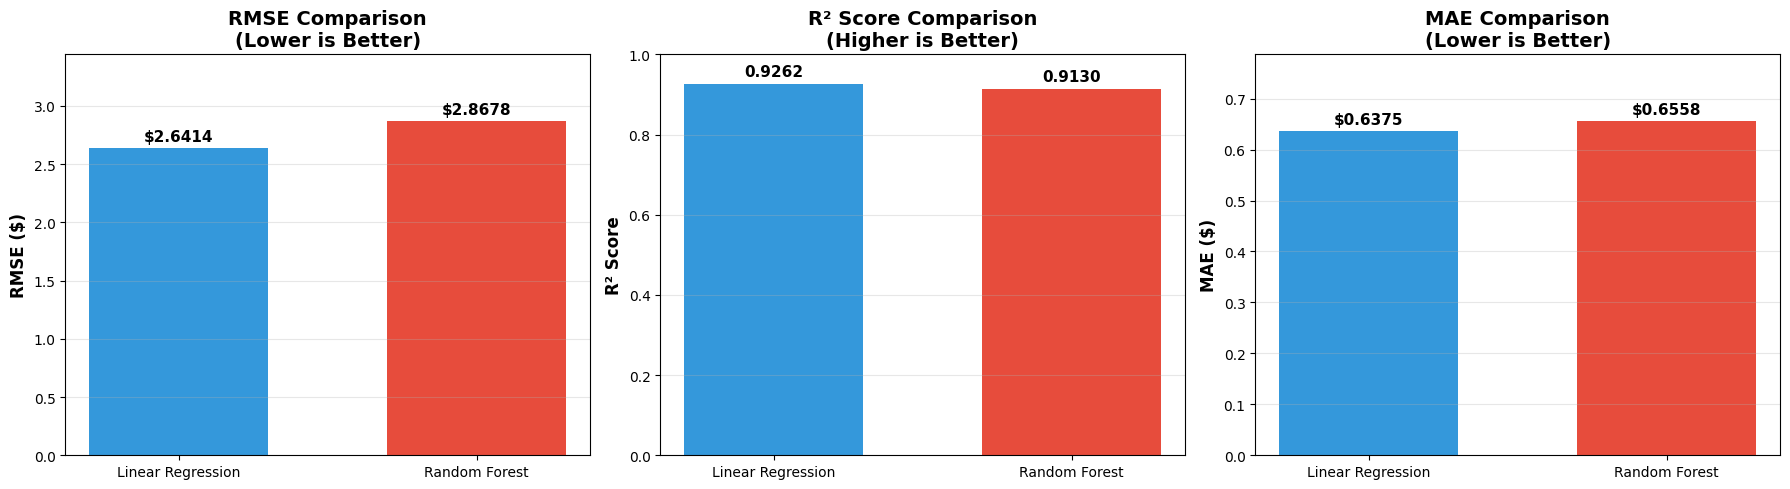

In [0]:
print("\n Generating performance comparison visualizations...")

import builtins

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['Linear Regression', 'Random Forest']
# Convert to float explicitly
rmse_values = [float(rmse_lr), float(rmse_rf)]
r2_values = [float(r2_lr), float(r2_rf)]
mae_values = [float(mae_lr), float(mae_rf)]

# RMSE Comparison
axes[0].bar(models, rmse_values, color=['#3498db', '#e74c3c'], width=0.6)
axes[0].set_ylabel('RMSE ($)', fontsize=12, fontweight='bold')
axes[0].set_title('RMSE Comparison\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, builtins.max(rmse_values) * 1.2)
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + builtins.max(rmse_values)*0.02, f'${v:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# R² Score Comparison
axes[1].bar(models, r2_values, color=['#3498db', '#e74c3c'], width=0.6)
axes[1].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1].set_title('R² Score Comparison\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate(r2_values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# MAE Comparison
axes[2].bar(models, mae_values, color=['#3498db', '#e74c3c'], width=0.6)
axes[2].set_ylabel('MAE ($)', fontsize=12, fontweight='bold')
axes[2].set_title('MAE Comparison\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[2].set_ylim(0, builtins.max(mae_values) * 1.2)
for i, v in enumerate(mae_values):
    axes[2].text(i, v + builtins.max(mae_values)*0.02, f'${v:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



 Generating actual vs predicted scatter plots...
Sampling predictions for visualization...


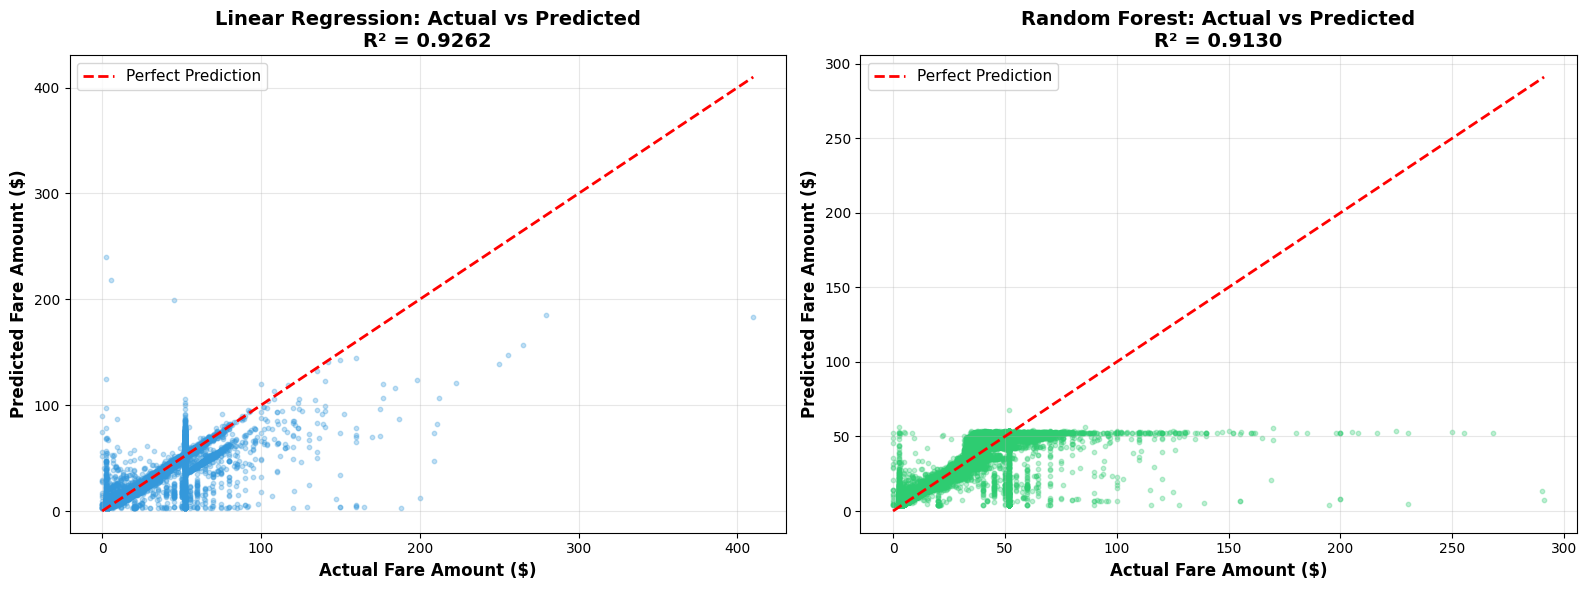

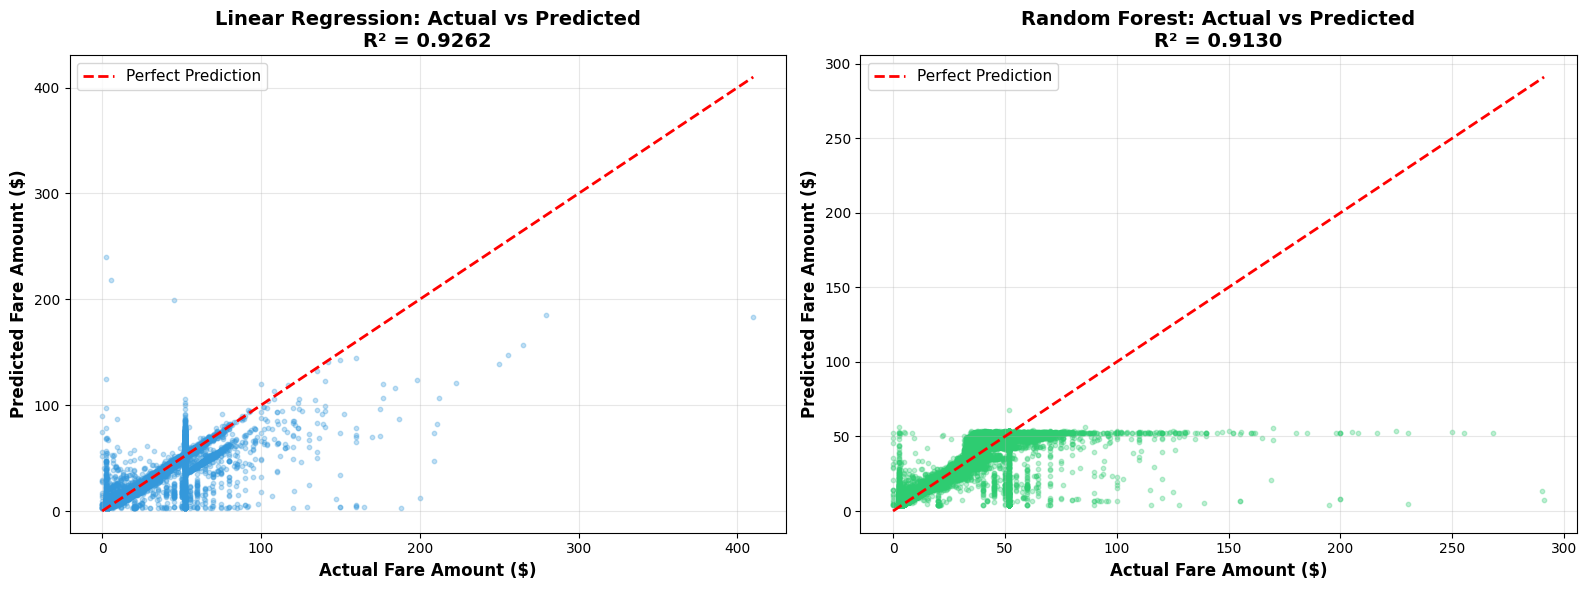

In [0]:


print("\n Generating actual vs predicted scatter plots...")


import builtins

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample data for plotting (10% to avoid memory issues)
print("Sampling predictions for visualization...")
lr_pred_pd = lr_predictions.select("fare_amount", "prediction").sample(0.1, seed=42).toPandas()
rf_pred_pd = rf_predictions.select("fare_amount", "prediction").sample(0.1, seed=42).toPandas()

# Linear Regression
axes[0].scatter(lr_pred_pd['fare_amount'], lr_pred_pd['prediction'], alpha=0.3, s=10, color='#3498db')
max_val_lr = builtins.max(lr_pred_pd['fare_amount'].max(), lr_pred_pd['prediction'].max())
axes[0].plot([0, max_val_lr], [0, max_val_lr], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Fare Amount ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Fare Amount ($)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Linear Regression: Actual vs Predicted\nR² = {float(r2_lr):.4f}', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(rf_pred_pd['fare_amount'], rf_pred_pd['prediction'], alpha=0.3, s=10, color='#2ecc71')
max_val_rf = builtins.max(rf_pred_pd['fare_amount'].max(), rf_pred_pd['prediction'].max())
axes[1].plot([0, max_val_rf], [0, max_val_rf], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Fare Amount ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Fare Amount ($)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Random Forest: Actual vs Predicted\nR² = {float(r2_rf):.4f}', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
display(fig)


 Generating feature importance plot...


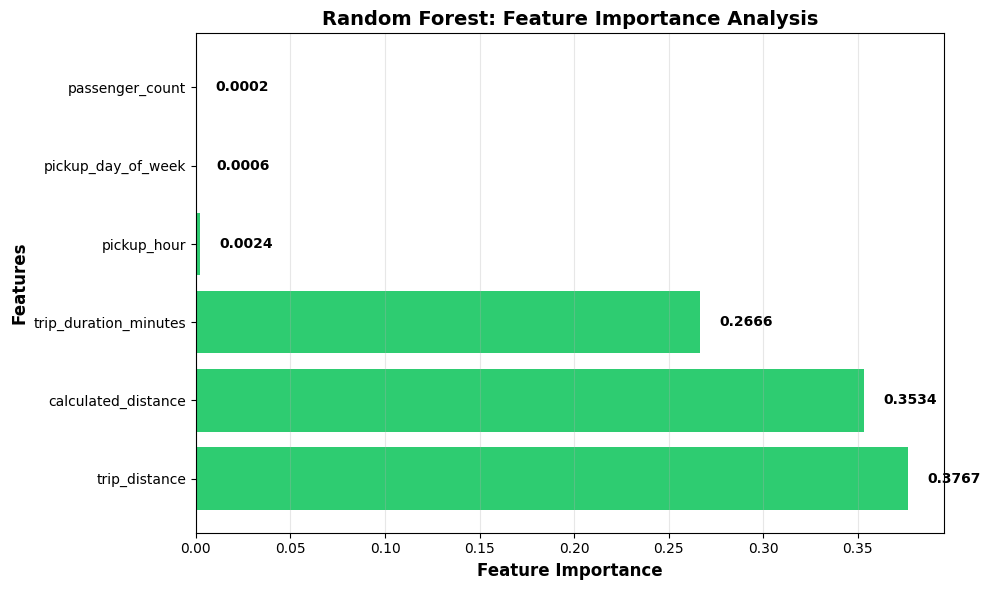


📝 Feature Importance Summary:
   - trip_distance: 0.3767
   - calculated_distance: 0.3534
   - trip_duration_minutes: 0.2666
   - pickup_hour: 0.0024
   - pickup_day_of_week: 0.0006
   - passenger_count: 0.0002


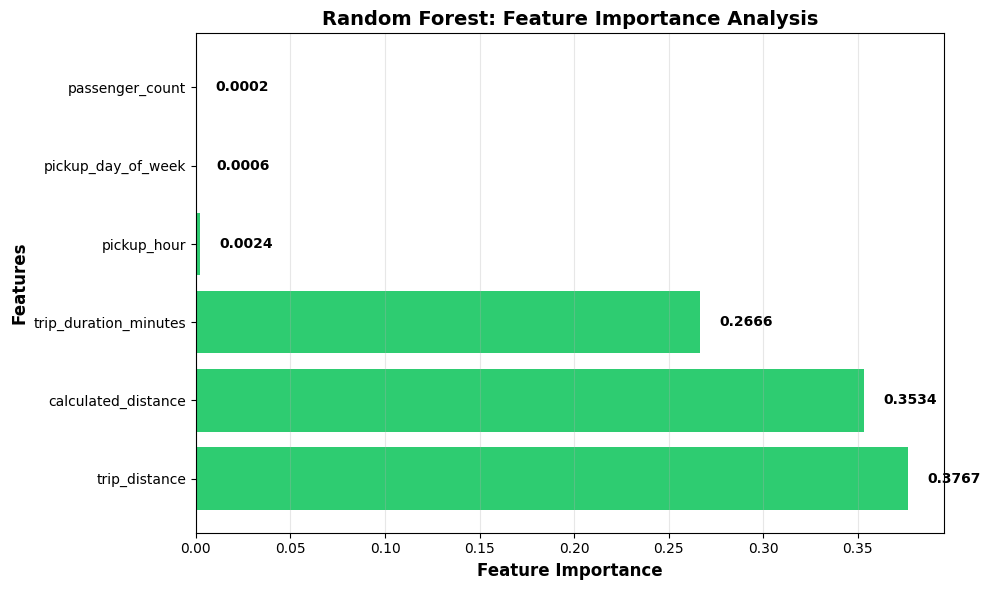

In [0]:
print("\n Generating feature importance plot...")

# Extract feature importance from Random Forest model
rf_model = best_rf_model.stages[-1]
feature_importance = rf_model.featureImportances.toArray()

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))
features_sorted = sorted(zip(regression_feature_cols, feature_importance), 
                        key=lambda x: x[1], reverse=True)
features, importances = zip(*features_sorted)

bars = ax.barh(features, importances, color='#2ecc71')
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: Feature Importance Analysis', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')


for i, (feature, importance) in enumerate(zip(features, importances)):
    ax.text(importance + 0.01, i, f'{importance:.4f}', va='center', fontweight='bold')

plt.tight_layout()
display(fig)

print("\n📝 Feature Importance Summary:")
for feature, importance in features_sorted:
    print(f"   - {feature}: {importance:.4f}")

In [0]:
# Save Linear Regression Pipeline
lr_pipeline_path = "/Volumes/main/ml_models/production/lr_regression_pipeline"
best_lr_model.write().overwrite().save(lr_pipeline_path)
print(f"Linear Regression pipeline saved to: {lr_pipeline_path}")

# Save Random Forest Pipeline
rf_pipeline_path = "/Volumes/main/ml_models/production/rf_regression_pipeline"
best_rf_model.write().overwrite().save(rf_pipeline_path)
print(f"Random Forest pipeline saved to: {rf_pipeline_path}")

In [0]:
from pyspark.ml import PipelineModel

# Load Linear Regression Pipeline
loaded_lr_model = PipelineModel.load(lr_pipeline_path)
print("Linear Regression pipeline loaded successfully")

# Load Random Forest Pipeline
loaded_rf_model = PipelineModel.load(rf_pipeline_path)
print("Random Forest pipeline loaded successfully")

# Use loaded pipeline for predictions
new_predictions = loaded_lr_model.transform(new_data)